<h1 style="color: green;">What drives the price of a car?</h1>

---


### Assignment Overview:

In this assignment, we are instructed to explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Our goal is to understand what factors make a car more or less expensive.  As a result of our analysis, we should provide clear recommendations to our client -- a used car dealership -- as to what consumers value in a used car. 

We are instructed to use the [CRISP-DM](https://en.wikipedia.org/wiki/Cross-industry_standard_process_for_data_mining) framework for the project.

 <h2 style="color: green;">[1.0] Business Understanding</h2>
 
 ---

The used car market is characterized by high volatility and complex pricing structures driven by a multitude of variables. For a dealership to remain competitive and profitable, it must move beyond "gut-feel" pricing and adopt a data-driven valuation strategy. The core challenge here is to identify and quantify the specific vehicle attributes (e.g. amke & model, odometer, age, fuel type, condition, etc.) that have the most significant impact on a vehicle's market value. By analyzing a dataset of 426,000 vehicles, this project aims to provide the client with a predictive framework that clarifies why certain cars command a premium and others do not.

It is worth noting that optimizing for dealer profit margin is outside of the scope of this model; we'll only be optimizing for sale price prediction (which represents value to the consumer). Value to the dealer would need to also consider acquisition cost, as this will determine their profit. Said another way, the cars that are priced the highest may not necessarily be the most profitable. Given this, we assume that our client (a used car dealership) has their own formula for calculating their expected profit when equipped with the acuisition cost (which they will obtain) and the predicted sale price (which our model will provide).

 <h2 style="color: green;">[2.0] Data Understanding</h2>

---

### Methodology:
For the Data Understanding phase of CRISP-DM, we'll use the dataset of 426k used cars and examine the metadata to better understand the form and content that is present. 
One of the most important early conclusions we'll need to draw is to verify that there is a well-populated feature for vehicle price, which will be the target feature of our model, as aligned with the Buiness Understanding. We'll also need to closely examine other features to understand what information they contain. 

#### [Data Structure & Sparse Rows]:
We'll look closely at the variance in non-null values across features, and decide how to handle null data case-by-case. In some cases it may be appropriate to drop the rows; in other cases it may be better to use [imputation](https://en.wikipedia.org/wiki/Imputation_(statistics)).

#### [Feature Data Types]:
We'll also look closely at the `dtype` of our features:

- **Numeric Features:** We'll examine their statistical properties (e.g. mean, median, standard deviation). 
- **Non-Numeric Fetaures:** We'll need to see which are categorical and determine an approach (generally, One-Hot Encoding for features with low cardiality, and Target Encoding for features with high cardinality. We will carefully manage the data to reduce risk of target leakage).


#### [Data Filtering Criteria]:
We'll identify data filtering criteria such as:

- **Outliers:** We'll look at variance in feature values and use statistical tools such as IQR to evaluate the data for outliers.
- **Redundant Features:** We'll need to think critically about whether there are redundant features in the data, so that we do not fall into the [Curse of Dimensionality](https://en.wikipedia.org/wiki/Curse_of_dimensionality).
- **Unneeded Features:** We'll see if any features are unneeded based on our output goals.

#### [Visual Examination]:
After undertaking some exploration of the data structure, properties and values, we'll also generate some plots of the data, for a visual examination. Additional properties or 
relationships in the data may become more apparent with a visual examination.

In [44]:
import copy
import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import set_config
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, PolynomialFeatures, StandardScaler, TargetEncoder

warnings.filterwarnings("ignore")
set_config(display="diagram")

In [ ]:
# Global utility functions

def draw_grid(axes, grid_axis="y"):
    """
    Convenience function for matplotlib plot grids.

    Args:
        axes: List of matplotlib Axis objects.
    """
    for ax in axes:
        ax.set_axisbelow(True)
        ax.grid(True, axis=grid_axis, linestyle="-", color="lightgray")

In [46]:
car_data = pd.read_csv("data/vehicles.csv")
car_data.sample(5)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
138754,7315285045,twin falls,28731,2016.0,ford,f-150,NaN,6 cylinders,gas,65844.0,clean,automatic,1FTEW1CG8GFB55213,rwd,NaN,truck,grey,id
6720,7308298913,anchorage / mat-su,25996,2015.0,dodge,charger,NaN,6 cylinders,gas,12089.0,clean,automatic,2C3CDXJG9FH875480,4wd,NaN,sedan,silver,ak
336406,7313845171,pittsburgh,7999,2011.0,ram,1500,NaN,NaN,other,194696.0,salvage,other,1D7RV1GT9BS517616,4wd,NaN,truck,NaN,pa
321007,7315292185,oregon coast,27990,2008.0,dodge,challenger,NaN,NaN,gas,54452.0,clean,automatic,2B3LJ74W18H300916,rwd,NaN,coupe,orange,or
195482,7311874275,central michigan,4495,2008.0,dodge,charger,NaN,NaN,gas,164573.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,mi


In [47]:
car_data.info()
car_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


In [48]:
Q1 = car_data["price"].quantile(0.25)
Q3 = car_data["price"].quantile(0.75)
IQR = Q3 - Q1
multiple = 1.5

price_lower_bound = Q1 - (multiple * IQR)
price_upper_bound = Q3 + (multiple * IQR)

<h2 style="color: green;">[2.1] Data Understanding - Initial Findings Based on Data Attributes</h2>

---

Initial examination of the data reveals some useful information as we think ahead to the Data Preparation phase:

1. There is a `price` feature which will serve as the target for the business problem we've defined, and it is fully populated.

1. The target feature -- `price` -- has good variation within 25 - 75% quartiles. There is an order-of-magnitude difference between 25% and 75% values (5900 USD vs. 26,485.75 USD), with an [IQR](https://en.wikipedia.org/wiki/Interquartile_range) of 20,585.75 USD.

1. The price feature also has wide outliers, based on eyeballing the min (0 USD) and max (3.7 billion) values as well as noting that the mean is higher than the 75% value (mean is skewed right by outliers). The standard deviation is also several orders of magnitude higher than the IQR. 
    - The max value for price is clearly an error -- no used car costs 3.7 billion -- and the min value of 0 USD also doesn't make sense for this purpose. We will need to filter.
    - However using `IQR * 1.5` in fence calculations probably isn't the best approach here -- since Q1 value is so low, the lower bound will be negative (0 USD values will be kept); and the upper bounds will only be set to 57,364.38 USD, which could exclude some luxury cars, which will create unintended bias in the model.
    - We'll start with a manual filter on price (>= 500 USD and <= 500k USD) before plotting, and finalize this approach during the Data Preparation phase.

1. There is also high variance in non-null values across attributes. The attribute with the lowest number of non-nulls (`size`) contains values such as 'compact'. A prelinminary assupmtion is that there could be some relationship between this categorical attribute and the final price, however since this value exists for only ~1/4 of the rows, it is not a good candidate for imputation and should be discarded. Fortunately there is another categorical attribute -- `type` -- which includes values such as 'truck', 'coupe', and 'sdean', which has values for ~3/4 of the rows, so this could be a suitable attribute to for signal related to the size of the vehicle (e.g. trucks will be larger than coupes).

1. `ID` and `VIN` are noise and can be discarded.

1. The `year` and `region` features also have a lot of variance.
    - `year` min value is 1900. For our model we can initially assume that cars > 40 years old could be considered "classic" and therefore out of the range that used car dealerships would target (unless they specialize in classic cars). We can filter on year and refine further during Data Preparation if needed.
    - An examination of `region` unique values reveals that they are inconsistent (e.g. cities, metros, and araes of states are all included) and very broad (400+ unique values). We can discard this data. A regional attirbution may be useful for identifying pricing trends, assuming it could be more streamlined. We'll explore whether a more meaningful regional association can be constructed from the `state` values during the Data Preparation phase.

1. The `odometer` feature is also somewhat noisy -- the max value is 10m miles, which seems unrealistic in a real-world used car market. We can safely assume that used car dealers likely wouldn't want to purchase a used car with > 300k miles (even that is arguably too high, but seems like a reasonable set of values to include for predictive purposes).

Next we will examine the data visually using Seaborn plots.

In [49]:
drop_columns = ["id", "VIN", "size", "region"]
dropna_subset = ["year"]

# Ignore IQR and use custom values.
price_lower_bound = 500
price_upper_bound = 500000
minimum_year = 1986
maximum_odometer = 300000.0

car_data_pre_filtered = (
    car_data.drop(columns=drop_columns)
    .dropna(subset=dropna_subset)
    .query(
        "price >= @price_lower_bound and price <= @price_upper_bound "
        "and year >= @minimum_year and odometer <= @maximum_odometer"
    )
    .sort_values(by="price")
)

car_data_pre_filtered["year"] = car_data_pre_filtered["year"].astype("int64")

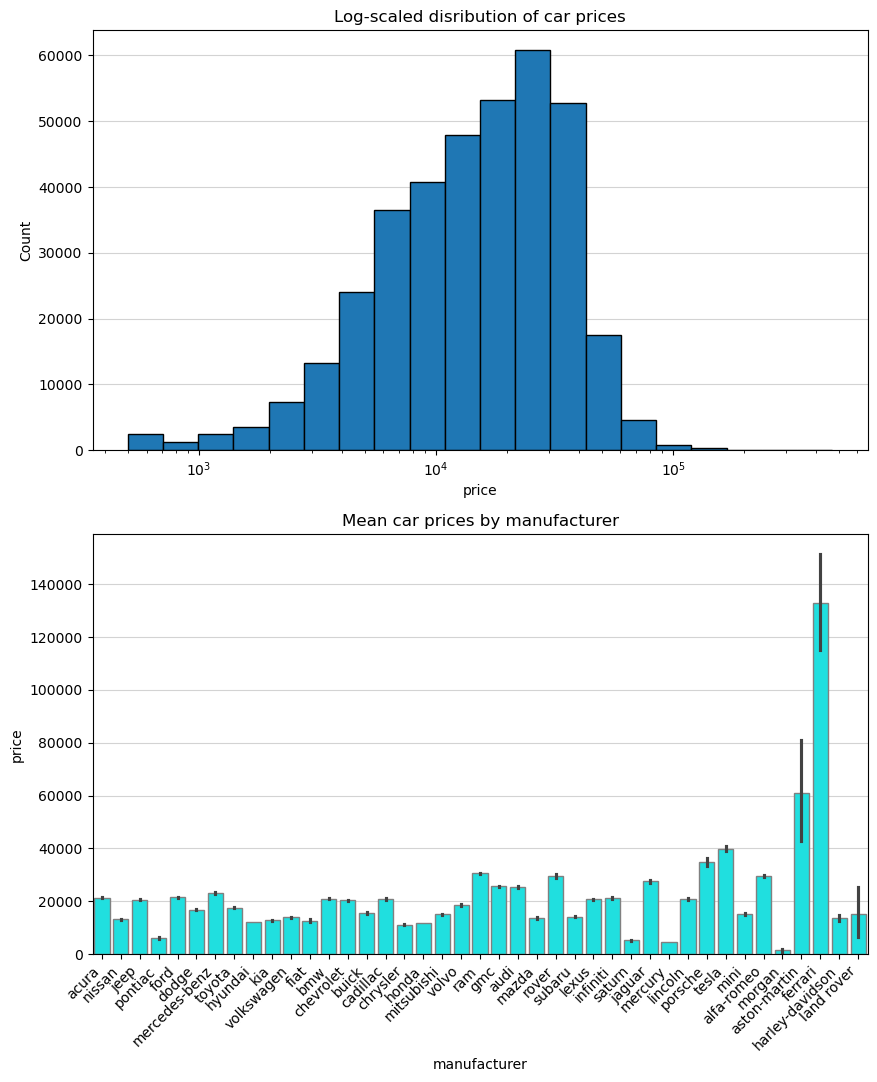

In [69]:
# Price
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 12))
draw_grid(axes)

axes[0] = sns.histplot(
    data=car_data_pre_filtered["price"],
    bins=20,
    log_scale=True,
    ax=axes[0],
    edgecolor="black",
    alpha=1,
)
axes[0].set_title("Log-scaled disribution of car prices")

sns.barplot(
    data=car_data_pre_filtered,
    x="manufacturer",
    y="price",
    ax=axes[1],
    color="cyan",
    edgecolor="gray",
)
axes[1].set_title("Mean car prices by manufacturer")

plt.xticks(rotation=45, horizontalalignment="right")
plt.savefig("images/car_prices.png")
plt.show()

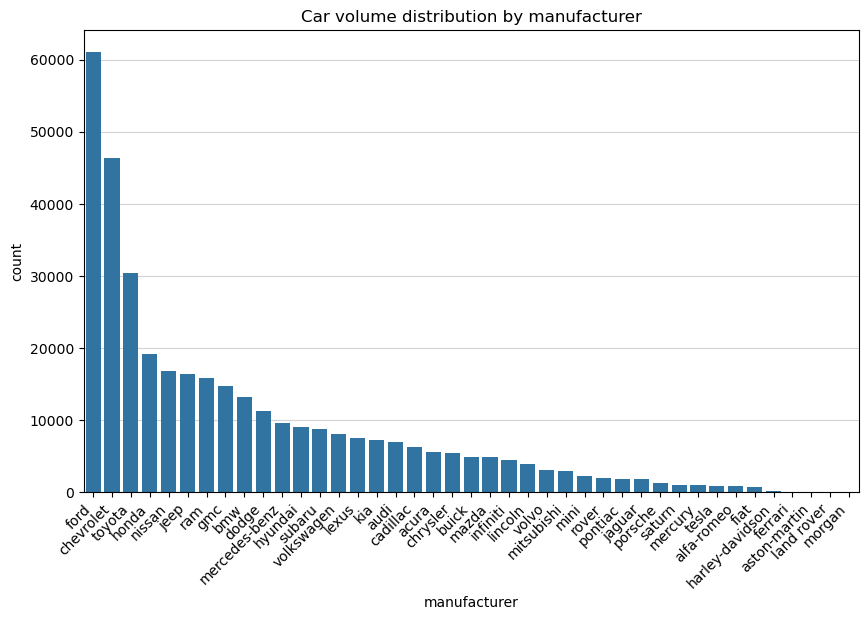

In [70]:
# Manufacturer
# ------------------------------------------------------------------------------
manufacturer_counts = car_data_pre_filtered["manufacturer"].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
draw_grid([ax])

sns.barplot(data=manufacturer_counts)
ax.set_title("Car volume distribution by manufacturer")

plt.xticks(rotation=45, horizontalalignment="right")
plt.savefig("images/manufacturer_volume.png")
plt.show()

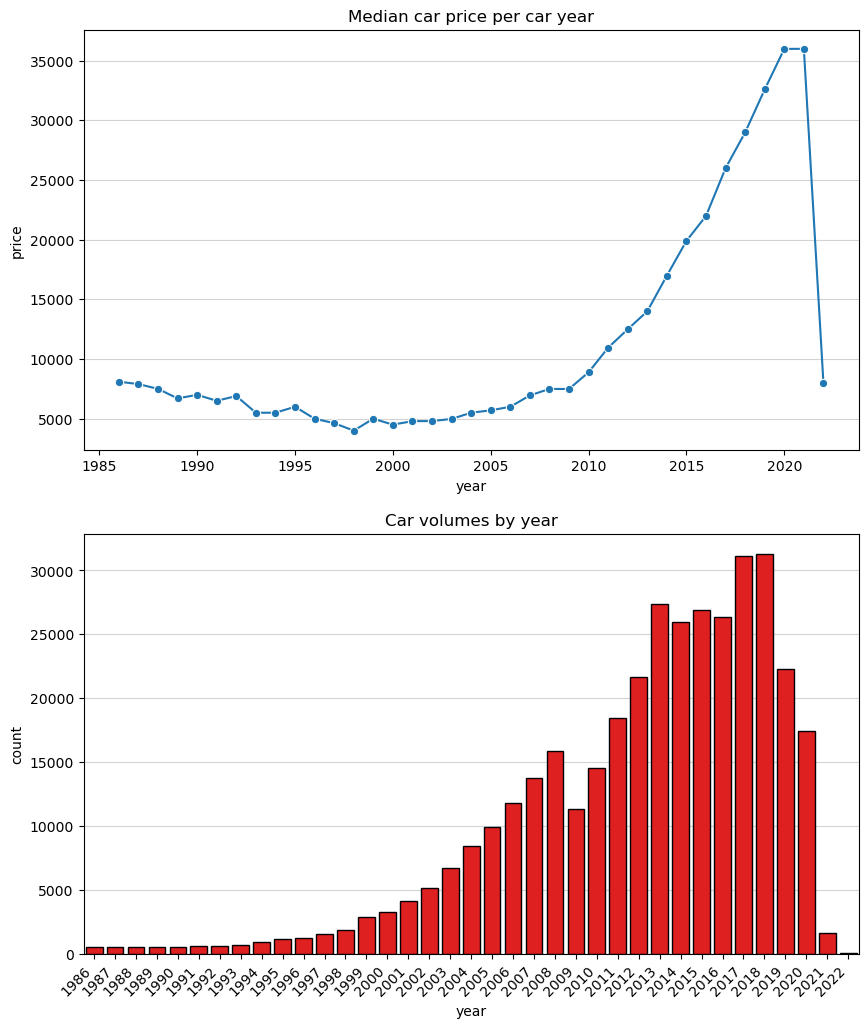

In [71]:
# Price & Volume
# ------------------------------------------------------------------------------
median_prices_per_year = car_data_pre_filtered.groupby("year")[
    ["price"]
].median()

fig, axes = plt.subplots(2, 1, figsize=(10, 12))
draw_grid(axes)

sns.lineplot(
    data=median_prices_per_year, x="year", y="price", marker="o", ax=axes[0]
)
axes[0].set_title("Median car price per car year")

# car_counts_by_year = car_data_pre_filtered.groupby('year').count()
sns.countplot(
    data=car_data_pre_filtered,
    x="year",
    ax=axes[1],
    color="red",
    edgecolor="black",
)
axes[1].set_title("Car volumes by year")

plt.xticks(rotation=45, horizontalalignment="right")
plt.savefig("images/median_price_and_volume_per_year.png")
plt.show()

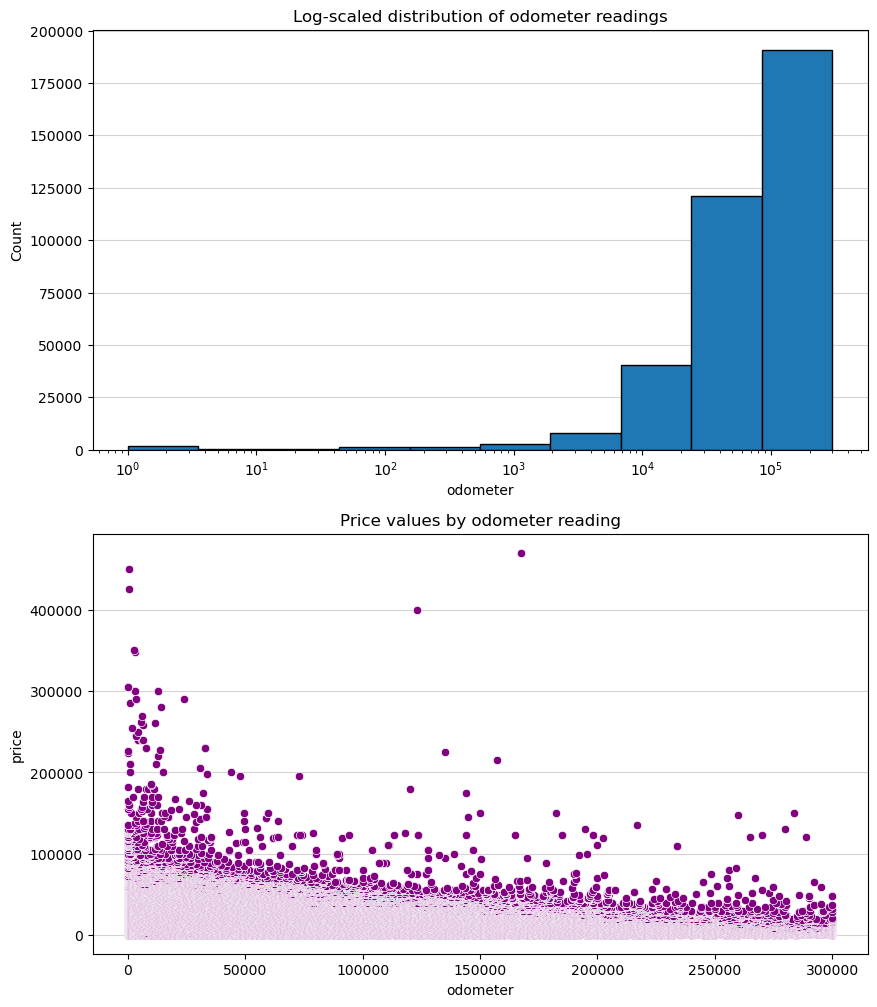

In [73]:
# Odometer
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 12))
draw_grid(axes)

sns.histplot(
    data=car_data_pre_filtered["odometer"],
    log_scale=True,
    bins=10,
    ax=axes[0],
    edgecolor="black",
    alpha=1,
)
axes[0].set_title("Log-scaled distribution of odometer readings")

sns.scatterplot(
    data=car_data_pre_filtered[["odometer", "price"]],
    x="odometer",
    y="price",
    ax=axes[1],
    color="purple",
)
axes[1].set_title("Price values by odometer reading")

plt.savefig("images/odometer.png")
plt.show()

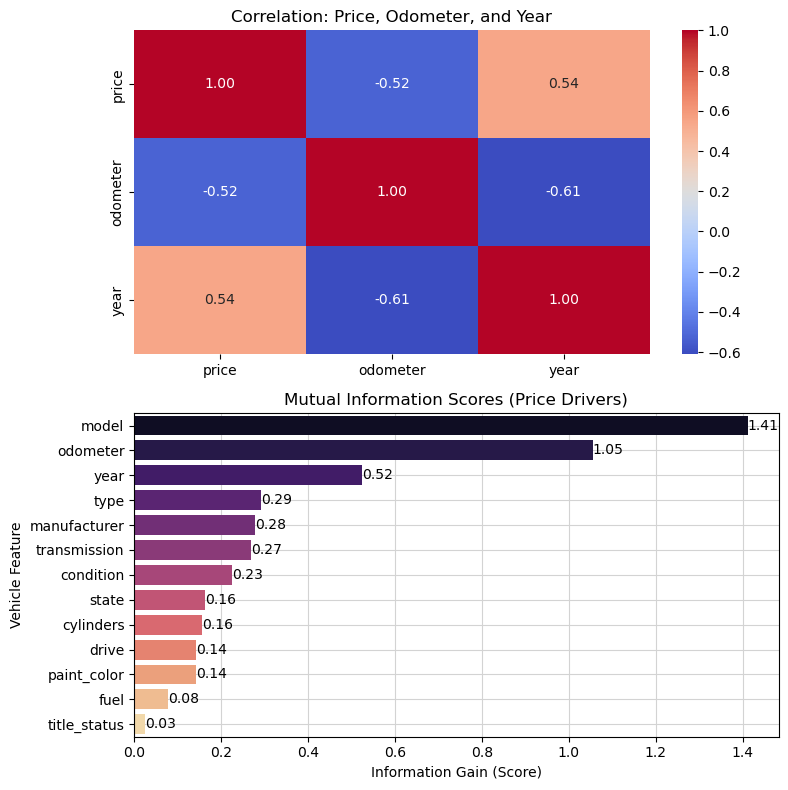

In [74]:
# Correlation & MI Score
# ------------------------------------------------------------------------------
corr_matrix = car_data_pre_filtered[["price", "odometer", "year"]].corr()

# Representative sample for speeding up MI. Must remove NaN's
mi_sample_df = car_data_pre_filtered.sample(100000, random_state=42).copy()
category_cols = mi_sample_df.select_dtypes(exclude=["number"]).columns.to_list()
mi_sample_df = mi_sample_df.dropna(
    subset=category_cols + ["year", "odometer", "price"]
)

X_mi = mi_sample_df[category_cols + ["year", "odometer"]]
y_mi = mi_sample_df["price"]

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_mi_encoded = X_mi.copy()
X_mi_encoded[category_cols] = encoder.fit_transform(X_mi[category_cols])

# discrete_features needs category column indices
mi_scores = mutual_info_regression(
    X_mi_encoded, y_mi, discrete_features=[0, 1, 2, 3, 4, 5, 6], random_state=42
)

mi_results = pd.Series(mi_scores, index=X_mi.columns).sort_values(
    ascending=False
)

fig, axes = plt.subplots(2, 1, figsize=(8, 8))
draw_grid(axes, grid_axis="both")

sns.heatmap(
    data=corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[0]
)
axes[0].set_title("Correlation: Price, Odometer, and Year")

sns.barplot(
    x=mi_results.values,
    y=mi_results.index,
    palette="magma",
    hue=mi_results.index,
    ax=axes[1],
)

axes[1].grid(True, axis="y", linestyle="-", color="lightgray")
axes[1].set_title("Mutual Information Scores (Price Drivers)")
axes[1].set_xlabel("Information Gain (Score)")
axes[1].set_ylabel("Vehicle Feature")

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', label_type='edge')

plt.tight_layout()
plt.savefig("images/correlation_and_mi.png")
plt.show()

In [55]:
# MI score is high for the model feature; check how many independent values.
model_check = car_data_pre_filtered.copy()
model_check["model"] = model_check["model"].fillna("unknown")
model_check = model_check[~model_check["model"].str.contains("\\$", regex=True)]

counts = model_check["model"].value_counts()
counts_df = counts.reset_index()
counts_df.columns = ["model", "count"]

print(f"total models: {len(counts)}")
print(f"total models with count > 5: {len(counts[counts > 5])}")

total models: 24666
total models with count > 5: 5577


<h2 style="color: green;">[2.2] Data Understanding - Conclusions:</h2>

---

The visual plots were helpful; they provided some additional insights about the data:

- Moderate positive correlation between `year` & `price` (newer cars are generally priced higher).
- Moderate negative correlation between `odometer` & `price` (lower mileage cars are generally priced higher). This is also reflected on the scatterplot.
- Some luxury brands (Ferrari, Aston-Martin) have high mean prices but the confidence interval for this signal is low -- volume for these brands is also very low relative to other manufacturers.
- The log-scaled distribution of `price` and `odometer` makes the variance easier to visualize.
- Pre-1996 volume is fairly low, and there is a dip in price between 1986 to 1996. This could indicate different things (e.g. perhaps 40 year old cars are starting to fall into the "classic" category). Since volume is low, we'll trim to a 30 year range for modelling.
- Year 2022 is relatively sparse, and prices drop sharply that year (likely not enough diversity in the volume), so we'll trim that year as well.
- The MI scores revealed strong information gain related to `model`, which is enticing. However looking more closely at the value counts and values for this feature it is clear that it's quite noisy -- model names include lots of variations, e.g. '1500' vs. 'silverado 1500' vs. '1500 crew cab big horn' are all variations of the same vehicle. Doing some analysis on the counts revels that there are 24666 unique values; 5577 of those have > 5 entries; 7749 > 3; 12404 > 1. So although it is a dirty long-tail distribution, there are still > 5k with > 5 entries, and the MI score is high, indicating this is a strong predictor. I'll attempt to clean the data (e.g. mapping long-tail categories to 'Other') in Data Preparation, rather than discard it outright. I'll have to be mindful of overfitting risk.
- The MI scores also confirmed that there is some information gain for features like `cylinders`, `drive`, `paint_color` as relates to `price` -- these pertain to vehicle trim options which are sometimes also part of the `model` name. There may be some redundancy in these features, and I am wary of the [Curse of Dimensionality](https://en.wikipedia.org/wiki/Curse_of_dimensionality); I'll make a final determination on whether to include them during Modelling.


<h2 style="color: green;">[3.0] Data Preparation</h2>

---

### Methodology:

**Data Cleanup**
1. **Data Structure:** Drop unneeded features, as informed by Data Understanding work.
1. **Data Filtering:** Filter rows based on boundary conditions.
1. **Data Cleanup:** String manipulation & consolidating long-tail categories into 'Other'.
1. **Type Conversion:** Modify data types as needed.
1. **Train-Test Split** on the cleaned data.

Using wrapper functions for execution for easier reuse later.

In [56]:
def clean_strings(df, columns):
    """
    String cleanup including special character removal.

    Returns:
        Updated DataFrame. 
    """
    for column in columns:
        df[column] = df[column].str.replace(r"[^a-zA-Z0-9\-_.]", "", regex=True)
        df[column] = df[column].str.lower().str.strip()
    return df


def clean_car_models(df, threshold=50):
    """
    Set bar for which models are classified as "Other"

    Returns:
        Updated DataFrame. 
    """
    # Handle literal "nan" strings created by previous cleanup
    df["model"] = df["model"].replace("nan", np.nan)

    # Remove Manufacturer from the start of the Model name
    # e.g., "ford f-150" -> "f-150"
    def remove_make(row):
        make = str(row["manufacturer"])
        model = str(row["model"])
        if model.startswith(make):
            return model[len(make) :].strip()
        return model

    df["model"] = df.apply(remove_make, axis=1)

    # Extract just the first two words for more consistent names
    # e.g. "silverado 1500 crew cab" and "silverado 1500 lariat" ->
    # "silverado 1500"
    df["model"] = df["model"].str.split().str[:2].str.join(" ")

    # Filter long tail
    model_counts = df["model"].value_counts()
    rare_models = model_counts[model_counts < threshold].index
    df.loc[df["model"].isin(rare_models), "model"] = "other"

    # Ensure actual NaNs are filled with 'other' so the SFS/Ridge doesn't see
    # them as missing
    df["model"] = df["model"].fillna("other")

    return df


def clean_car_data(
    drop_columns,
    price_lower_bound,
    price_upper_bound,
    maximum_year,
    num_years,
    maximum_odometer,
    model_threshhold,
):
    """
    Filter & clean the car data.

    Args:
        drop_columns: Columns to drop.
        price_lower_bound: Price floor, inclusive.
        price_upper_bound: Price ceiling, inclusive.
        maximum_year: Year ceiling, inclusive.
        num_years: Year range, backwards from maximum_year.
        maximum_odometer: Odometer ceiling, inclusive.
        model_threshhold: Models with value counts below this value are set to
            "other".

    Returns:
        Updated DataFrame. 
    """
    cleaned_df_ = car_data.copy()

    minimum_year_ = maximum_year - num_years

    # Apply filter bounds
    cleaned_df_ = (
        cleaned_df_.drop(columns=drop_columns)
        .query(
            "price >= @price_lower_bound and price <= @price_upper_bound "
            "and year >= @minimum_year_ and year <= @maximum_year and "
            "odometer <= @maximum_odometer"
        )
        .sort_values(by="price")
    )

    # Add Region
    states_df_ = pd.read_csv("data/states_to_regions.csv")
    states_df_.drop(columns=["State", "Division"], inplace=True)
    states_df_ = states_df_.rename(
        columns={"State Code": "state", "Region": "region"}
    )

    cleaned_df_["state"] = cleaned_df_["state"].str.upper()
    cleaned_df_ = pd.merge(cleaned_df_, states_df_, on="state", how="left")

    cleaned_df_ = clean_strings(
        cleaned_df_, cleaned_df_.select_dtypes(exclude=["number"]).columns
    )

    cleaned_df_ = clean_car_models(cleaned_df_, model_threshhold)
    cleaned_df_["state"] = cleaned_df_["state"].str.upper()
    cleaned_df_["year"] = cleaned_df_["year"].astype("int64")

    # Ensure no NaNs in target for imputation
    cleaned_df_ = cleaned_df_.dropna(subset=["price"])

    return cleaned_df_


cleaned_df = clean_car_data(
    drop_columns=["id", "VIN", "size", "region"],
    price_lower_bound=500,
    price_upper_bound=500000,
    maximum_year=2021,
    num_years=30,
    maximum_odometer=300000.0,
    model_threshhold=10,
)

<h2 style="color: green;">[4.0] Modelling</h2>

---

### Methodology:

**Data Processing Pipeline**

1. **Data Transformations:** Imputation, encoding, Polynomialfeatures, scaling.
1. **Preprocessor Pipeline** Selectively applies data transformations via ColumnTransformer.

**Model Development**

1. **SFS**: Use SFS to find the best features + best number of features. Using manual SFS approach
in order to store result data for each incremental feature (allows us to answer the key question in
1.0 Business Understanding).
1. **Test Multiple Models** using the best feature set from SFS
1. **GridSearchCV** for hyperparameter tuning

Using wrapper functions for execution for easier reuse later.

In [57]:
def get_model_pipeline(
    regressor,
    features_to_use,
    num_cols,
    low_card_cols,
    high_card_cols,
    cat_constant_cols,
):
    """
    Builds a pipeline tailored to the specific subset of features. Features are
    transformed based on their type.

    Args:
        regressor: Regression model to use in pipeline on log-scaled target.
        features_to_use: List of all feature names to use in model.
        num_cols: List of numeric feature names.
        low_card_cols: List of feature names with low cardinality.
        high_card_cols: List of feature names with high cardinality.
        cat_constant_cols: List of feature names with constant categories.

    Returns:
        A pipeline with a ColumnTransformer & TransformedTargetRegressor.
    """
    # Filter the features by type.
    filtered_num = [c for c in num_cols if c in features_to_use]
    filtered_low_card = [c for c in low_card_cols if c in features_to_use]
    filtered_high = [c for c in high_card_cols if c in features_to_use]
    filtered_const = [c for c in cat_constant_cols if c in features_to_use]

    transformers = []

    if filtered_num:
        numeric_transformer = Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                (
                    "poly",
                    PolynomialFeatures(include_bias=False),
                ),  # Degree is tuned in GridSearchCV
                ("scaler", StandardScaler()),
            ]
        )
        transformers.append(("num", numeric_transformer, filtered_num))
    if filtered_low_card:
        low_card_transformer = Pipeline(
            [
                ("imputer", SimpleImputer(strategy="most_frequent")),
                # Dense output for consistency wtih PolynomialFeatures and TargetEncoder
                (
                    "ohe",
                    OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                ),
            ]
        )
        transformers.append(
            ("low_card", low_card_transformer, filtered_low_card)
        )
    if filtered_high:
        high_card_transformer = Pipeline(
            [
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "target",
                    TargetEncoder(target_type="continuous", smooth="auto"),
                ),
            ]
        )
        transformers.append(("high_card", high_card_transformer, filtered_high))
    if filtered_const:
        constant_transformer = Pipeline(
            [
                (
                    "imputer",
                    SimpleImputer(strategy="constant", fill_value="unknown"),
                ),
                (
                    "ohe",
                    OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                ),
            ]
        )
        transformers.append(("constant", constant_transformer, filtered_const))

    preprocessor = ColumnTransformer(
        transformers=transformers, remainder="drop"
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "regressor",
                TransformedTargetRegressor(
                    regressor=regressor,  # Target is log-transformed.
                    func=np.log1p,
                    inverse_func=np.expm1,
                ),
            ),
        ]
    )

In [58]:
def find_best_features(
    X_train_full,
    y_train_full,
    X_eval_sample,
    y_eval_sample,
    X_test_full,
    y_test_full,
):
    """
    Manual implementation of SFS so that we can record feature selection +
    full suite of eval metrics at each step, i.e. direct impact of each
    inremental feature.

    Args:
        X_train_full: Full X_train data set.
        y_train_full: Full y_train data set.
        X_eval_sample: Representative X_train sample (for processing speed).
        y_eval_sample: Used for scoring during SFS eval.
        X_test_full: Full X_test data set for model eval with selected features.
        y_test_full: Full y_test data set for model eval with selected features.
    
    Returns:
        A list of dicts containing features added at each pass with eval scores.
    """
    remaining_features = list(X_train_full.columns)
    current_features = []
    history = []

    num_cols = ["year", "odometer"]
    low_card_cols = [
        "type",
        "transmission",
        "cylinders",
        "drive",
        "fuel",
        "region",
        "title_status",
    ]
    high_card_cols = ["model", "manufacturer", "state"]
    cat_constant_cols = ["paint_color", "condition"]

    # Step through each feature and score not only R2 but also MAE, etc.
    # for later comparison
    for i in range(1, len(X_train_full.columns) + 1):
        best_step_score = -np.inf
        best_feature = None

        # Identify the best of the remaining features
        for feature in remaining_features:
            trial_features = current_features + [feature]

            pipe = get_model_pipeline(
                regressor=Ridge(alpha=0.1),  # hardcoded for SFS consistency.
                features_to_use=trial_features,
                num_cols=num_cols,
                low_card_cols=low_card_cols,
                high_card_cols=high_card_cols,
                cat_constant_cols=cat_constant_cols,
            )

            # Use sample for fitting for speed
            pipe.fit(X_eval_sample[trial_features], y_eval_sample)
            score = pipe.score(X_eval_sample[trial_features], y_eval_sample)

            if score > best_step_score:
                best_step_score = score
                best_feature = feature

        current_features.append(best_feature)
        remaining_features.remove(best_feature)

        # Evaluation Phase: Train on FULL train set and score on FULL test set
        final_pipe = get_model_pipeline(
            regressor=Ridge(alpha=0.1),
            features_to_use=current_features,
            num_cols=num_cols,
            low_card_cols=low_card_cols,
            high_card_cols=high_card_cols,
            cat_constant_cols=cat_constant_cols,
        )

        final_pipe.fit(X_train_full[current_features], y_train_full)
        preds = final_pipe.predict(X_test_full[current_features])

        # Final metrics for each feature
        history.append(
            {
                "Step": i,
                "Feature Added": best_feature,
                "R2": r2_score(y_test_full, preds),
                "MAE": mean_absolute_error(y_test_full, preds),
                "MedAE": median_absolute_error(y_test_full, preds),
                "MAPE": mean_absolute_percentage_error(y_test_full, preds),
            }
        )

    return history

In [59]:
def evaluate_sfs(df):
    """
    Create the train_test splits and evluate SFS models.

    Args:
        df: DataFrame to use in SFS.

    Returns:
        A list of dicts containing features added at each pass with eval scores.
    """
    results = []
    
    X = df.drop(columns=["price"])
    y = df["price"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # SFS sample: We use 20k rows to find the "Best Feature" each round (speed).
    # We still evaluate on the full test set for accuracy evaluation.round
    # y_sfs_sample is a testing sample from the training data set, so that we don't
    # have accidental data leakage when doing the quick 'best feature' eval.
    X_sfs_sample, _, y_sfs_sample, _ = train_test_split(
        X_train, y_train, train_size=20000, random_state=42
    )

    results = find_best_features(
        X_train_full=X_train,
        y_train_full=y_train,
        X_eval_sample=X_sfs_sample,
        y_eval_sample=y_sfs_sample,
        X_test_full=X_test,
        y_test_full=y_test,
    )

    return results

In [60]:
def plot_sfs_elbow(results):
    """
    Visual plot of SFS impact on R2.

    Args:
        results: DF with results data for plot.
    """
    feature_impact_df = pd.DataFrame(results)
    plot_r2 = feature_impact_df["R2"].values

    formatted_df = feature_impact_df.copy()
    formatted_df["R2"] = formatted_df["R2"].map("{:.2%}".format)
    formatted_df["MAE"] = formatted_df["MAE"].map("${:,.0f}".format)
    formatted_df["MedAE"] = formatted_df["MedAE"].map("${:,.0f}".format)
    formatted_df["MAPE"] = formatted_df["MAPE"].map("{:.2%}".format)

    print("\n--- FINAL FEATURE IMPACT TABLE ---")
    print(formatted_df.to_string(index=False))

    # --------------------------------------------------------------------------
    # R2 plot
    # --------------------------------------------------------------------------
    plt.figure(figsize=(10, 5))

    # Use the 'Step' column from your dataframe so the dimensions ALWAYS match
    plt.plot(
        feature_impact_df["Step"],
        plot_r2,
        marker="o",
        color="forestgreen",
        linewidth=2,
    )

    plt.title("R2 vs. Feature Count")
    plt.xlabel("Number of Features in Model")
    plt.ylabel("Explained Variance (R2)")

    # Set the x-ticks to match the actual steps found
    plt.xticks(feature_impact_df["Step"])

    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()


--- FINAL FEATURE IMPACT TABLE ---
 Step Feature Added     R2    MAE  MedAE   MAPE
    1          year 33.62% $7,827 $4,950 80.54%
    2     cylinders 44.98% $6,889 $4,134 75.26%
    3          fuel 51.75% $6,478 $3,997 73.67%
    4  manufacturer 55.71% $6,193 $3,844 72.71%
    5      odometer 58.43% $5,898 $3,574 71.14%
    6          type 59.91% $5,664 $3,313 67.95%
    7         drive 60.84% $5,567 $3,253 67.73%
    8     condition 61.36% $5,524 $3,210 66.94%
    9  title_status 61.69% $5,476 $3,178 66.56%
   10         state 61.88% $5,446 $3,157 66.56%
   11   paint_color 61.94% $5,456 $3,165 64.99%
   12        region 61.96% $5,449 $3,157 65.14%
   13  transmission 61.60% $5,465 $3,158 64.64%
   14         model 43.48% $5,121 $2,771 59.21%


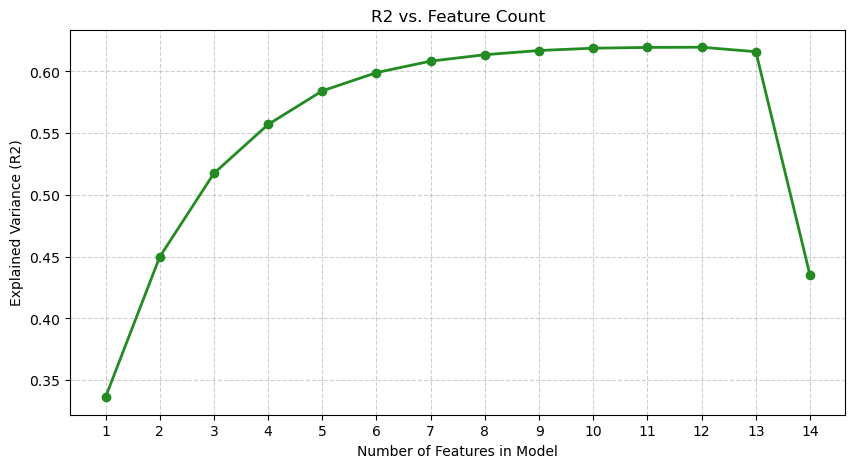

In [61]:
eval_results = evaluate_sfs(cleaned_df)
plot_sfs_elbow(eval_results)

<h2 style="color: green;">[4.1] Modelling - Review Results</h2>

At this stage I realized there are some problems with my approach:

1. R2 for the SFS loop drops sharply at the end when `model` is added -- this is unexpected
1. Looking at the metrics table, MAPE is very high throughout (~60% at best)

Instead of moving forward with Modelling, I'll try new parameters for `model`. 
It's likely that the threshhold value is too low, resulting in too much noise in the model categories.


--- FINAL FEATURE IMPACT TABLE ---
 Step Feature Added     R2    MAE  MedAE   MAPE
    1          year 33.62% $7,827 $4,950 80.54%
    2         model 42.35% $6,673 $3,773 68.91%
    3     cylinders 48.94% $6,333 $3,625 67.89%
    4          fuel 52.57% $6,095 $3,520 67.72%
    5      odometer 55.41% $5,797 $3,289 66.14%
    6          type 57.69% $5,589 $3,136 64.63%
    7  manufacturer 60.09% $5,454 $3,033 64.61%
    8     condition 61.48% $5,310 $2,970 64.07%
    9         state 61.74% $5,275 $2,948 64.03%
   10         drive 62.33% $5,233 $2,943 63.87%
   11  title_status 62.63% $5,189 $2,908 63.54%
   12        region 62.72% $5,175 $2,897 63.74%
   13  transmission 62.79% $5,177 $2,898 63.65%
   14   paint_color 62.71% $5,195 $2,921 62.06%


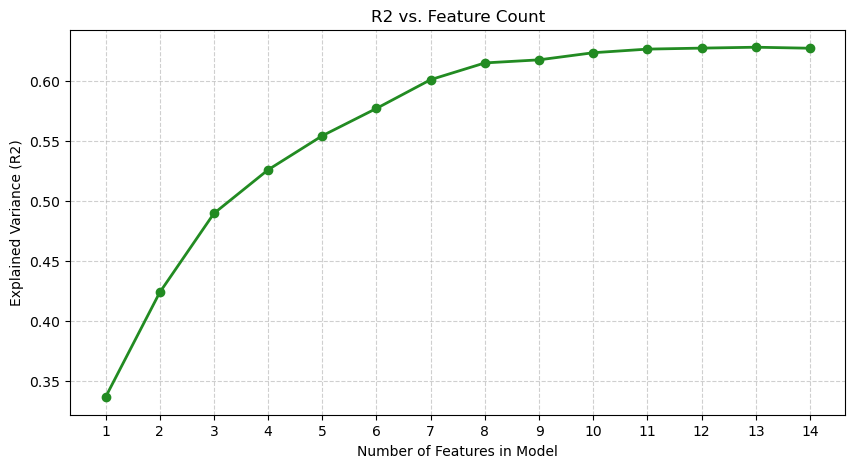

In [62]:
# Rerun SFS on adjusted parameters
cleaned_df_2 = clean_car_data(
    drop_columns=["id", "VIN", "size", "region"],
    price_lower_bound=500,
    price_upper_bound=500000,
    maximum_year=2021,
    num_years=30,
    maximum_odometer=300000.0,
    model_threshhold=50,
)

eval_results_2 = evaluate_sfs(cleaned_df_2)
plot_sfs_elbow(eval_results_2)

<h2 style="color: green;">[4.2] Modelling - Review 2nd Batch Results</h2>

---

The issue with `model` was addressed by raising the threshhold -- r2 no longer drops. But MAPE is still high (62%+)

I realized that some of my other filter values may be too broad, so I made some adjustments:

1. `price_lower_bound` -- raised to 2,500 to filter out very low value cars.
1. `price_upper_bound` -- lowered to 1000,000 to keep the more expensive cars out.
1. `num_years` -- lowered to 15, to further focus on more recent used cars.
1. `maximum_odometer` -- lowered to 200k, to remove very high-mileage vehicles (regardless of vehicle age).


--- FINAL FEATURE IMPACT TABLE ---
 Step Feature Added     R2    MAE  MedAE   MAPE
    1          year 34.97% $7,973 $5,674 44.72%
    2         model 52.49% $6,177 $3,849 31.96%
    3     cylinders 58.67% $5,854 $3,711 30.34%
    4          fuel 61.07% $5,705 $3,633 29.84%
    5      odometer 64.12% $5,407 $3,407 27.98%
    6         drive 66.78% $5,192 $3,280 27.24%
    7  manufacturer 68.41% $5,070 $3,146 26.71%
    8     condition 69.62% $4,945 $3,078 26.27%
    9  title_status 70.29% $4,887 $3,024 25.84%
   10          type 71.26% $4,770 $2,955 25.08%
   11        region 71.63% $4,730 $2,936 24.84%
   12   paint_color 71.58% $4,728 $2,923 24.80%
   13         state 71.61% $4,717 $2,922 24.73%
   14  transmission 71.66% $4,714 $2,922 24.74%


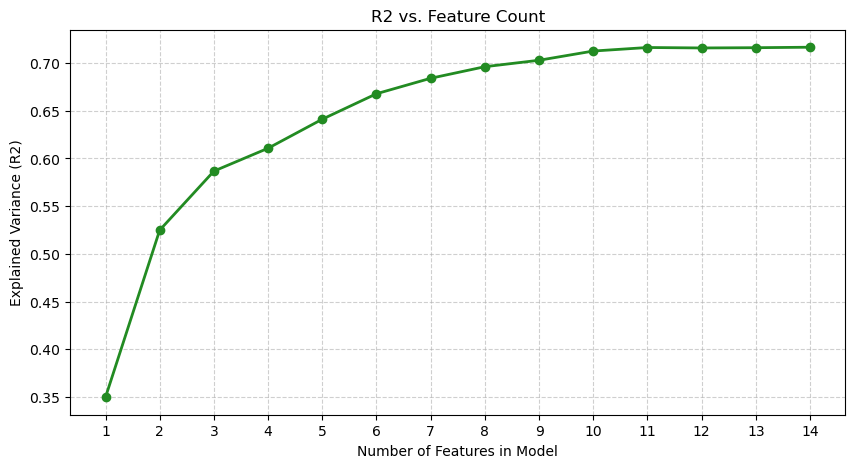

In [63]:
# Rerun SFS on adjusted data
cleaned_df_3 = clean_car_data(
    drop_columns=["id", "VIN", "size", "region"],
    price_lower_bound=2500,
    price_upper_bound=100000,
    maximum_year=2021,
    num_years=15,
    maximum_odometer=200000.0,
    model_threshhold=50,
)

eval_results_3 = evaluate_sfs(cleaned_df_3)
plot_sfs_elbow(eval_results_3)

<h2 style="color: green;">[4.3] Modelling - Review 3rd Batch Results</h2>

---

Results look much better -- R2 is stable, MAE and MedAE decrease with additinal features, MAPE drops to ~25%.

**Elbow plot learnings:** performance gains with these filters level off significantly after 10 features. We can remove the additional features and focus on tuning the hyperparameters with `GridSearchCv`. 

To ensure we have the best model, I'll also compare a `Ridge` model to `Lasso` as well as a `LinearRegression` model as a baeline. 

All 3 models will be optimized with the same data.

*Note:* There are other regression models to consider as well, e.g. `ElasticNet` and `RandomForrest`. Gradient Boost is also a possibility. At this stage in the course we haven't covered those yet, but will in coming weeks. So we will stick with `Ridge` and `Lasso` for now.

In [64]:
model_df = cleaned_df_3.copy()
model_sfs_results = copy.deepcopy(eval_results_3)

num_cols = ["year", "odometer"]
low_card_cols = [
    "type",
    "transmission",
    "cylinders",
    "drive",
    "fuel",
    "region",
    "title_status",
]
high_card_cols = ["model", "manufacturer", "state"]
cat_constant_cols = ["paint_color", "condition"]

X = model_df.drop(columns=["price"])
y = model_df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [65]:
# Take the best features from SFS and run them through 
sfs_col_end = 10
top_cols = [step['Feature Added'] for step in model_sfs_results[:sfs_col_end]]

# Model eval loop
# LinearRegression will be baseline
models_to_test = {
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {},
    },
    "Ridge": {
        "model": Ridge(),
        "params": {
            "preprocessor__num__poly__degree": [1, 2, 3, 4],
            "regressor__regressor__alpha": [0.1, 1.0, 10.0, 100.0, 1000.0],
        },
    },
    "Lasso": {
        "model": Lasso(),
        "params": {
            "preprocessor__num__poly__degree": [1, 2, 3],
            "regressor__regressor__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0],
            # Increasing max_iter because using small alphas (longer convergence time)
            "regressor__regressor__max_iter": [20000],
            "regressor__regressor__tol": [0.005]
        },
    }
}

results_list = []
best_estimators = {}

for name, config in models_to_test.items():

    #ttr = TransformedTargetRegressor(
    #    regressor=config["model"], func=np.log1p, inverse_func=np.expm1
    #)
    #pipe = Pipeline([("preprocessor", preprocessor), ("regressor", ttr)])

    pipe=get_model_pipeline(
        regressor=config["model"],
        features_to_use=top_cols,
        num_cols = num_cols,
        low_card_cols = low_card_cols,
        high_card_cols = high_card_cols,
        cat_constant_cols = cat_constant_cols
    )

    # Tuning / Fitting
    if config["params"]:
        search = GridSearchCV(
            pipe,
            config["params"],
            cv=3,
            scoring="neg_mean_absolute_error",
            n_jobs=1 # single thread to avoid OS error
        )
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
    else:
        best_model = pipe.fit(X_train, y_train)

    best_estimators[name] = best_model

    # Calculate Performance & Overfitting Gap
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    result = {
        "Model": name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Gap %": ((test_mae - train_mae) / train_mae) * 100,
        "Test MAPE": mean_absolute_percentage_error(y_test, y_test_pred),
        "Test R2": r2_score(y_test, y_test_pred),
    }
    results_list.append(result)

              Model    Train MAE     Test MAE     Gap %  Test MAPE   Test R2
1             Ridge  4734.921598  4724.684571 -0.216203   0.247208  0.713242
2             Lasso  4752.756871  4741.826144 -0.229987   0.248645  0.712528
0  LinearRegression  4772.308838  4760.117290 -0.255464   0.250302  0.713305


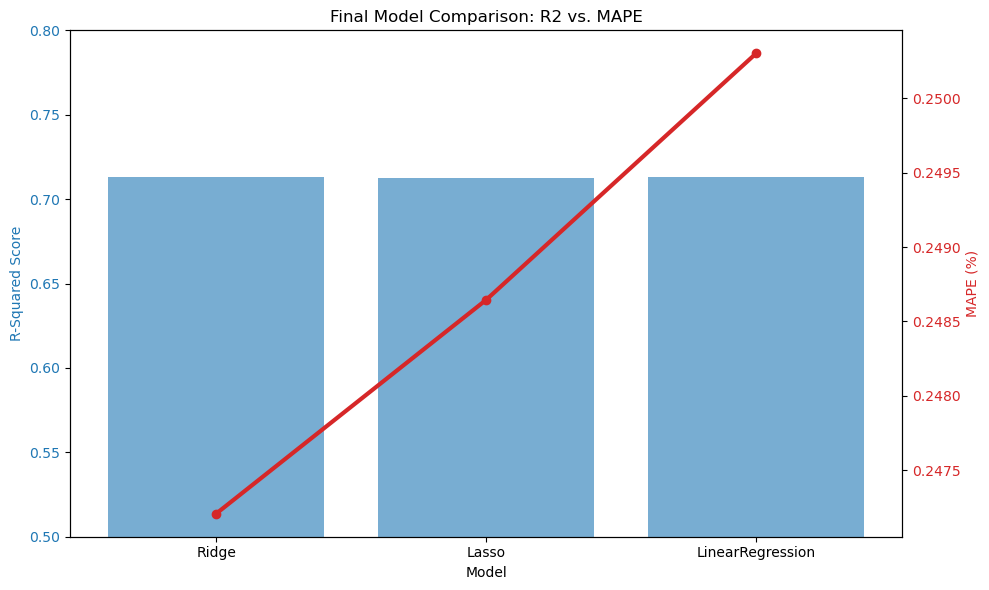

In [75]:
# Plot final results.
df_results = pd.DataFrame(results_list).sort_values(by='Test MAPE')
print(df_results.head())


fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot R2 Scores
ax1.set_xlabel('Model')
ax1.set_ylabel('R-Squared Score', color='tab:blue')
ax1.bar(df_results['Model'], df_results['Test R2'], color='tab:blue', alpha=0.6, label='Test R2')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_ylim(0.5, 0.8) # Zoom in on the relevant area

# Plot MAPE on secondary axis
ax2 = ax1.twinx()
ax2.set_ylabel('MAPE (%)', color='tab:red')
ax2.plot(df_results['Model'], df_results['Test MAPE'], color='tab:red', marker='o', linewidth=3, label='MAPE %')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Final Model Comparison: R2 vs. MAPE')
fig.tight_layout()

plt.savefig("images/model_scores.png")
plt.show()

<h2 style="color: green;">[5.0] Evaluation</h2>

---

All 3 models are showing comparable results on the test data, with `Ridge` having the lowest MAPE.

Based on the model evaluation metrics:

1. **MAE & MedAE:** MAE ($4,724) vs. MedAE (~$2,960) indicates that outliers (e.g. cars that are hard to price, such as heavily modified cars) have an impact on pricing. Our model is very accurate for "normal" cars, but it occasionally makes larger errors on rare or unique vehicles.
1. **$R^2$ (71.3%):** Our model explains 71.3% of why one car costs more than another, based solely on data (e.g. "human emotion" is removed from the equation). 
1. **MAPE (24.7%):** On average, our model's price prediction is within ~25% of the actual market value.

**Most Impactful Features**

Beacuse we ran SFS iteratively we also have good data on the impact of each feature on the final R2 score (see plot below). The top 3 (in order) are `year`, `model`, `cylinders`, which account for ~58% of car pricing. These features are heavily valued by consumers, as are the other 7 shown in the plot.

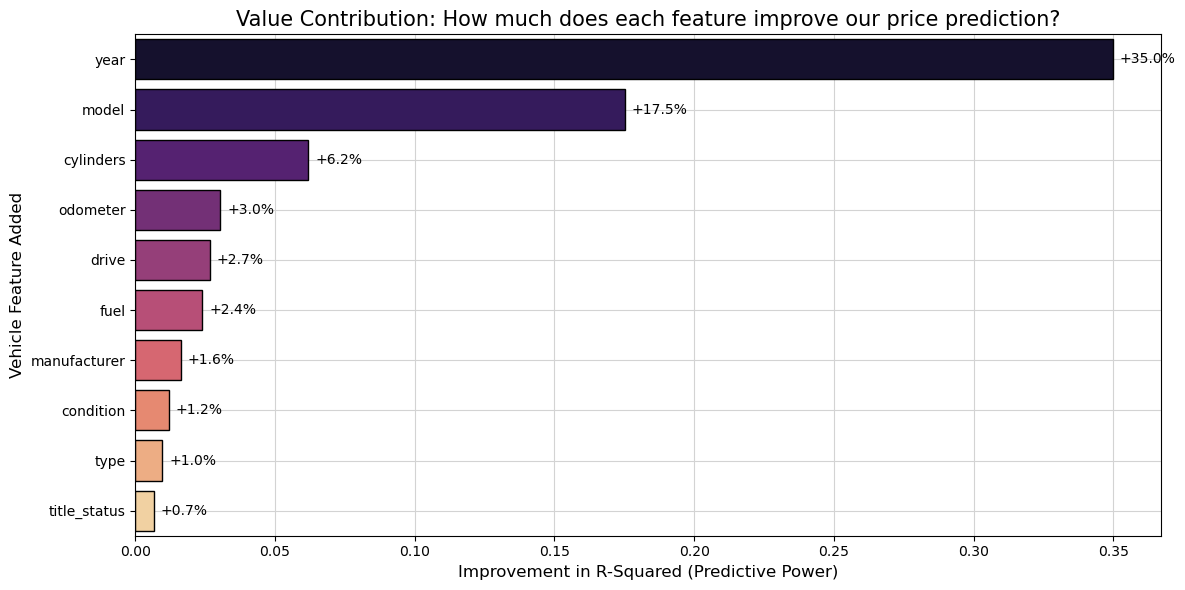

In [76]:
# 1. Convert the first 10 steps of history into a DataFrame
# Assuming 'Feature Added' and 'Score' (R2) are the keys in your history dicts
df_history = pd.DataFrame(eval_results_3[:10])

# 2. Calculate the "Marginal Improvement"
# This shows exactly how much R2 increased when that specific feature was added
df_history["Marginal_Gain"] = (
    df_history["R2"].diff().fillna(df_history["R2"].iloc[0])
)
df_history = df_history.sort_values(by="Marginal_Gain", ascending=False)

# 3. Plotting the "Predictive Power" contribution
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_history,
    x="Marginal_Gain",
    y="Feature Added",
    palette="magma",
    edgecolor="black",
)
draw_grid([ax], grid_axis="both")

# Add percentage labels to show the client the exact 'weight' of the feature
for p in ax.patches:
    ax.annotate(
        f"+{p.get_width():.1%}",
        (p.get_width(), p.get_y() + p.get_height() / 2),
        ha="left",
        va="center",
        fontsize=10,
        xytext=(5, 0),
        textcoords="offset points",
    )

plt.title(
    "Value Contribution: How much does each feature improve our price prediction?",
    fontsize=15,
)
plt.xlabel("Improvement in R-Squared (Predictive Power)", fontsize=12)
plt.ylabel("Vehicle Feature Added", fontsize=12)
plt.tight_layout()

plt.savefig("images/r2_feature_comparison.png")
plt.show()

<h2 style="color: green;">[6.0] Deployment</h2>

---

Please see the project README.md file for the final report.

## Original Assignment Instructions

---


## What drives the price of a car?

![](images/kurt.jpeg)

**ASSIGNMENT OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding Instructions:

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

### Data Understanding Instructions:

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

### Data Preparation Instructions:

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

### Modeling Instructions:

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

### Evaluation Instructions:

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Deployment Instructions:

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.